# Brownian Motion, GBM, OU

## Why this matters

Every continuous-time financial model is built on **Brownian motion** (BM, Wiener process). You can't have a meaningful conversation about stochastic vol, term-structure models, or Itô calculus without it.

You will be asked at any quant interview:
1. State the four defining properties of BM.
2. Why is BM nowhere differentiable?
3. **Geometric Brownian motion (GBM)** — derive its solution from the SDE.
4. Ornstein-Uhlenbeck (OU) — when is it used?
5. Simulate, compute moments, compare to closed forms.

This notebook covers all five with simulation + theory.

## The four defining properties of BM

A standard Brownian motion $W_t$ satisfies:

1. $W_0 = 0$.
2. **Independent increments**: $W_{t+s} - W_t$ is independent of the path up to $t$.
3. **Stationary Gaussian increments**: $W_{t+s} - W_t \sim \mathcal{N}(0, s)$.
4. **Continuous paths** (almost surely).

**Key consequence**: $W_t$ is **nowhere differentiable** with probability 1. The variance scales linearly with time, so velocity ($\propto 1/\sqrt{dt}$) blows up. This is why we need stochastic calculus, not ordinary calculus.

### Three SDEs you must know

| Process | SDE | Solution |
|---|---|---|
| **BM** | $dX = dW$ | $X_t = W_t$ |
| **Drifted BM** | $dX = \mu \, dt + \sigma \, dW$ | $X_t = X_0 + \mu t + \sigma W_t$ |
| **GBM** (geometric BM) | $dS = \mu S \, dt + \sigma S \, dW$ | $S_t = S_0 \exp((\mu - \sigma^2/2) t + \sigma W_t)$ |
| **OU** (mean-reverting) | $dX = \theta(\mu - X) dt + \sigma dW$ | $X_t = X_0 e^{-\theta t} + \mu(1-e^{-\theta t}) + \sigma \int_0^t e^{-\theta(t-s)} dW_s$ |

## Setup

In [1]:
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(42)


def simulate_bm(T, n_steps, n_paths, seed=42):
    rng = np.random.default_rng(seed)
    dt = T / n_steps
    dW = rng.standard_normal((n_paths, n_steps)) * np.sqrt(dt)
    W = np.zeros((n_paths, n_steps + 1))
    W[:, 1:] = np.cumsum(dW, axis=1)
    return np.linspace(0, T, n_steps + 1), W


def simulate_gbm(S0, mu, sigma, T, n_steps, n_paths, seed=42):
    rng = np.random.default_rng(seed)
    dt = T / n_steps
    Z = rng.standard_normal((n_paths, n_steps))
    log_returns = (mu - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z
    log_S = np.zeros((n_paths, n_steps + 1))
    log_S[:, 0] = np.log(S0)
    log_S[:, 1:] = np.log(S0) + np.cumsum(log_returns, axis=1)
    return np.linspace(0, T, n_steps + 1), np.exp(log_S)


def simulate_ou(X0, theta, mu, sigma, T, n_steps, n_paths, seed=42):
    """Exact discretisation of OU."""
    rng = np.random.default_rng(seed)
    dt = T / n_steps
    e = np.exp(-theta * dt)
    s = sigma * np.sqrt((1 - e**2) / (2*theta))
    X = np.zeros((n_paths, n_steps + 1))
    X[:, 0] = X0
    Z = rng.standard_normal((n_paths, n_steps))
    for t in range(n_steps):
        X[:, t+1] = X[:, t]*e + mu*(1-e) + s*Z[:, t]
    return np.linspace(0, T, n_steps + 1), X

print('Simulators defined.')

Simulators defined.


## Simulate and verify moments

BM at T = 1:
  Empirical mean:     0.0015  (theory: 0)
  Empirical variance: 0.9917  (theory: 1)
  Empirical skew:     -0.0199  (theory: 0)
  Excess kurt:        -0.0451  (theory: 0)


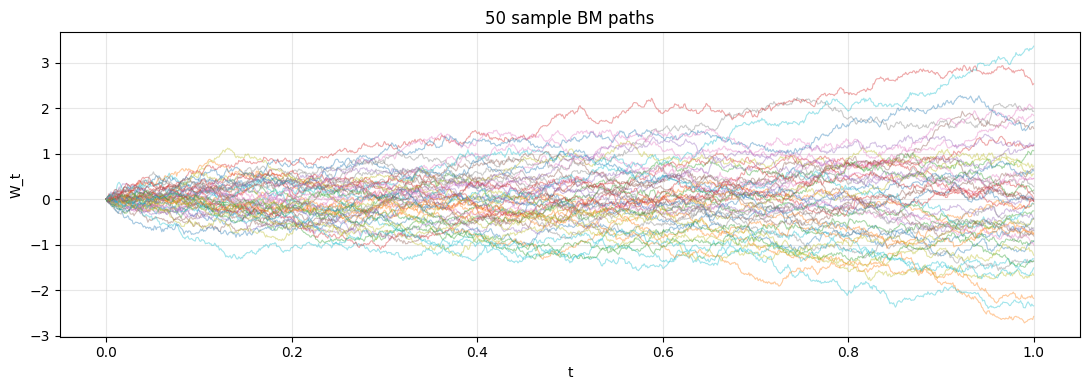

In [2]:
# BM at time T should have mean 0 and variance T
T = 1.0
t_grid, W = simulate_bm(T, 1000, 10000)

print('BM at T = 1:')
print(f'  Empirical mean:     {W[:,-1].mean():.4f}  (theory: 0)')
print(f'  Empirical variance: {W[:,-1].var():.4f}  (theory: 1)')
print(f'  Empirical skew:     {stats.skew(W[:,-1]):+.4f}  (theory: 0)')
print(f'  Excess kurt:        {stats.kurtosis(W[:,-1]):+.4f}  (theory: 0)')

# Plot 50 sample paths
fig, ax = plt.subplots(figsize=(11, 4))
for i in range(50):
    ax.plot(t_grid, W[i], alpha=0.4, lw=0.8)
ax.set_xlabel('t'); ax.set_ylabel('W_t')
ax.set_title('50 sample BM paths')
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## Quadratic variation — the BM trademark

For ordinary differentiable functions, $\sum (\Delta f)^2 \to 0$ as $\Delta t \to 0$ (it's $O(\Delta t)$). For BM:

$$\langle W \rangle_T := \sum_i (W_{t_{i+1}} - W_{t_i})^2 \to T \quad \text{as} \; \max \Delta t \to 0$$

This is the **quadratic variation** of BM. Verify numerically.

In [3]:
# Quadratic variation
n_grid = [100, 1000, 10000]
t_grid_test = []
qv = []
for n in n_grid:
    t_g, W = simulate_bm(1.0, n, 1, seed=0)
    qv.append((np.diff(W[0])**2).sum())
    t_grid_test.append(n)

print('QV of one BM path on [0, 1]:')
for n, q in zip(t_grid_test, qv):
    print(f'  n_steps = {n:>5}: QV = {q:.4f}  (theory: 1.0000)')
print('\n→ Converges to T = 1 regardless of grid resolution.')

QV of one BM path on [0, 1]:
  n_steps =   100: QV = 0.9323  (theory: 1.0000)
  n_steps =  1000: QV = 0.9564  (theory: 1.0000)
  n_steps = 10000: QV = 0.9962  (theory: 1.0000)

→ Converges to T = 1 regardless of grid resolution.


## GBM — the BS underlying

GBM at T=1:
  Empirical mean:  105.1980  (theory: 105.1271)
  Empirical median: 100.6151  (theory: 100.5013)
  Variance ratio:  1.0117  (theory: 1)


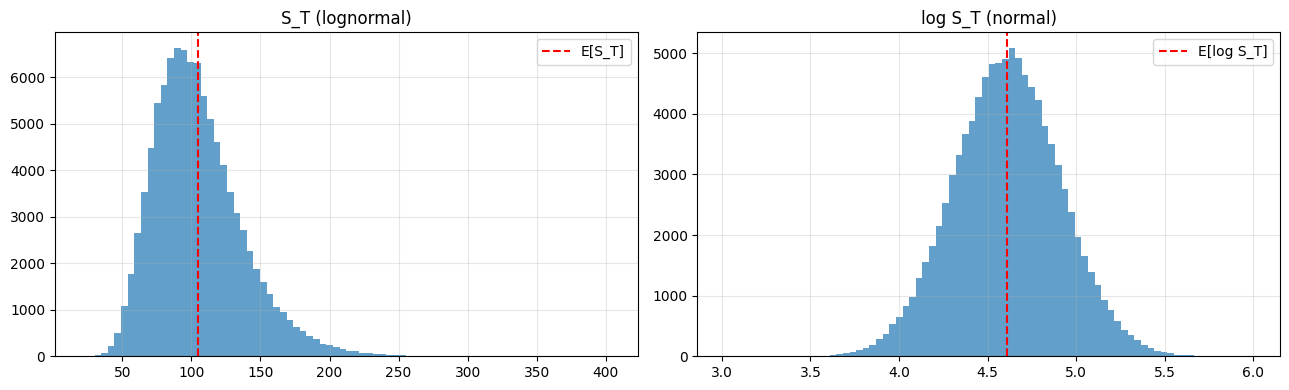

In [4]:
# GBM with S0 = 100, μ = 0.05, σ = 0.30, T = 1y
S0, mu, sigma, T = 100, 0.05, 0.30, 1.0
t_grid, S = simulate_gbm(S0, mu, sigma, T, 252, 100000)

# E[S_T] = S0 * exp(μT)
print(f'GBM at T=1:')
print(f'  Empirical mean:  {S[:,-1].mean():.4f}  (theory: {S0*np.exp(mu*T):.4f})')
print(f'  Empirical median: {np.median(S[:,-1]):.4f}  (theory: {S0*np.exp((mu-0.5*sigma**2)*T):.4f})')
print(f'  Variance ratio:  {S[:,-1].var() / (S0**2 * np.exp(2*mu*T) * (np.exp(sigma**2*T) - 1)):.4f}  (theory: 1)')

# Plot histogram of log(S_T) — should be normal
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(S[:, -1], bins=80, alpha=0.7)
axes[0].axvline(S0*np.exp(mu*T), color='red', ls='--', label='E[S_T]')
axes[0].set_title('S_T (lognormal)'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].hist(np.log(S[:, -1]), bins=80, alpha=0.7)
axes[1].axvline(np.log(S0) + (mu - 0.5*sigma**2)*T, color='red', ls='--', label='E[log S_T]')
axes[1].set_title('log S_T (normal)'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Ornstein-Uhlenbeck — mean reversion

OU is the simplest mean-reverting process. Used for:
- **Interest rate models** (Vasicek)
- **Spread / cointegration** trading
- **Volatility-of-vol** in some frameworks

$$dX_t = \theta(\mu - X_t)\,dt + \sigma\,dW_t$$

Three parameters: $\theta$ (mean-reversion speed), $\mu$ (long-run mean), $\sigma$ (vol). Stationary distribution: $\mathcal{N}(\mu, \sigma^2/(2\theta))$. Half-life of mean reversion: $\ln 2 / \theta$.

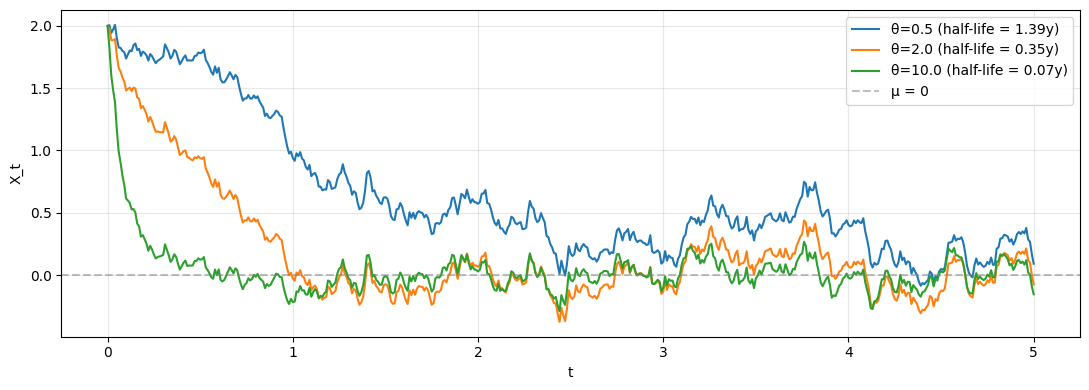

→ Higher θ = faster mean reversion. Half-life is the time for half the deviation to decay.


In [5]:
# Compare OU paths with different θ (mean-reversion speed)
fig, ax = plt.subplots(figsize=(11, 4))
for theta in [0.5, 2.0, 10.0]:
    t_g, X = simulate_ou(X0=2.0, theta=theta, mu=0.0, sigma=0.5, T=5.0, n_steps=500, n_paths=1, seed=42)
    ax.plot(t_g, X[0], label=f'θ={theta} (half-life = {np.log(2)/theta:.2f}y)')
ax.axhline(0.0, color='gray', ls='--', alpha=0.5, label='μ = 0')
ax.set_xlabel('t'); ax.set_ylabel('X_t'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print('→ Higher θ = faster mean reversion. Half-life is the time for half the deviation to decay.')

## Exercises

### Exercise 1 — BM scaling

Verify that $W_{ct} \overset{d}{=} \sqrt{c} \cdot W_t$ (Brownian scaling).

In [6]:
# Your answer here


<details>
<summary><b>Reveal solution</b></summary>

```python
t_g, W1 = simulate_bm(1.0, 1000, 10000, seed=0)
t_g, W2 = simulate_bm(4.0, 4000, 10000, seed=1)
# W_4 should have variance 4
print(f'W_4 variance: {W2[:,-1].var():.4f}  (theory: 4.0)')
print(f'W_1 * 2 variance: {(W1[:,-1]*2).var():.4f}  (theory: 4.0)')
```

_Both equal 4 to MC error. BM has scaling exponent 1/2._

</details>

### Exercise 2 — GBM percentile

For GBM with S0=100, μ=0.05, σ=0.30, T=1: what's the 5th percentile of S_T?

In [7]:
# Your answer here


<details>
<summary><b>Reveal solution</b></summary>

```python
from scipy.stats import lognorm
S0, mu, sigma, T = 100, 0.05, 0.30, 1.0
mean_log = np.log(S0) + (mu - 0.5*sigma**2)*T
std_log = sigma * np.sqrt(T)
percentile_5 = np.exp(mean_log + std_log * stats.norm.ppf(0.05))
print(f'5th percentile of S_T: {percentile_5:.4f}')

t_g, S = simulate_gbm(S0, mu, sigma, T, 252, 100000)
mc_5 = np.quantile(S[:,-1], 0.05)
print(f'MC 5th percentile:    {mc_5:.4f}')
```

_About 64-65 — closed form and MC agree._

</details>

### Exercise 3 — OU stationary distribution

Simulate OU for T=20 (well past half-life). Verify the empirical distribution matches the stationary $\mathcal{N}(\mu, \sigma^2/(2\theta))$.

In [8]:
# Your answer here


<details>
<summary><b>Reveal solution</b></summary>

```python
theta, mu, sigma = 2.0, 0.0, 0.5
t_g, X = simulate_ou(X0=2.0, theta=theta, mu=mu, sigma=sigma, T=20.0, n_steps=2000, n_paths=10000, seed=42)
emp_mean = X[:, -1].mean()
emp_var = X[:, -1].var()
theo_mean = mu
theo_var = sigma**2 / (2*theta)
print(f'Empirical mean:      {emp_mean:+.4f}  (theory: {theo_mean:+.4f})')
print(f'Empirical variance:  {emp_var:.4f}  (theory: {theo_var:.4f})')
```

_After many half-lives, OU converges to its stationary distribution._

</details>

## Interview Q&A

**Q: State the four properties of BM.**

A: $W_0 = 0$; independent increments; $W_{t+s} - W_t \sim N(0, s)$; continuous paths a.s.

**Q: Why is BM nowhere differentiable?**

A: Variance of $\Delta W = W_{t+\Delta} - W_t$ is $\Delta$, so std is $\sqrt{\Delta}$. Velocity = $\Delta W / \Delta \propto 1/\sqrt{\Delta}$, which diverges as $\Delta \to 0$. Hence no derivative.

**Q: Solve $dS = \mu S \, dt + \sigma S \, dW$.**

A: Apply Itô to $f(S) = \ln S$: $d \ln S = (\mu - \sigma^2/2) dt + \sigma dW$. Integrate: $\ln S_t = \ln S_0 + (\mu - \sigma^2/2) t + \sigma W_t$. Exponentiate: $S_t = S_0 \exp((\mu - \sigma^2/2) t + \sigma W_t)$.

**Q: $E[S_t]$ for GBM?**

A: $S_0 e^{\mu t}$. The $-\sigma^2/2$ in the exponent is exactly compensated by the lognormal expectation correction: $E[e^X] = e^{\mu_X + \sigma_X^2/2}$ for normal $X$.

**Q: When is OU vs GBM appropriate?**

A: OU when the variable is **mean-reverting** (interest rates, vol, spreads). GBM when the variable is **multiplicative** with no anchor (stock prices, exchange rates). OU can go negative; GBM stays positive.

**Q: What's the half-life of OU?**

A: $\ln 2 / \theta$. Time for half the initial deviation from $\mu$ to decay. Used to interpret $\theta$ in pairs trading.

## Pitfalls

| Pitfall | Issue | Fix |
|---|---|---|
| Naïve Euler-Maruyama on stiff SDEs | Numerical instability for large $\theta$ | Use exact discretisation for OU; Milstein or implicit schemes |
| Confusing $\mu$ in GBM | Drift in BS world is $r - q$ (Q-measure), not historical $\mu$ | State the measure |
| Mean-variance scaling errors | Random number generation in $(n_paths, n_steps)$ shape | Always check shapes |
| OU half-life vs $\theta$ | Different references use different signs | $\tau_{1/2} = \ln 2 / \theta$ for $dX = \theta(\mu - X) dt + ...$ |
| Forgetting the $-\sigma^2/2$ in GBM | Confusing arithmetic vs geometric mean | Drift in log-space ≠ drift in price-space |

## What you've earned

After this notebook you can:

1. **State** the four BM properties and explain non-differentiability.
2. **Simulate** BM, GBM, OU correctly and verify moments.
3. **Derive** the GBM solution via Itô on $\ln S$.
4. **Distinguish** when OU vs GBM is appropriate.

Next: **`02_ito_and_gbm.ipynb`** — Itô's lemma applied to the standard models.